# CMSC320 Programming Assignment 7
Please go through the file following the instructions as you go.

Rename this notebook to `CMSC320_PA6_YourName.ipynb`

In this notebook you'll generate a synthetic dataset and implement the Perceptron algorithm.

In [1]:
# This is the place to import everything that you'll use later. Feel free to come back to this
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Run this for reproducibility
np.random.seed(30)

## Q1 (9 points). Generate a synthetic dataset and convert it into a pandas DataFrame

Create a dataframe that has 1000 rows, and columns x1, x2, and label. The label should be -1 or 1, with a roughly 50/50 split among classes. The data should be linearly separable.

Feel free to visualize the data as you go about making it to make sure it's linearly separable, but delete visualization cells after (you'll visualize your final data in Q3).

In [2]:
# Answer Q1 here
# Feel free to create extra cells before the next one, if helpful

# generating linearly separable data (1000 rows)

n_rows = 1000

# creating two clusters of points
# class -1: centered around (2, 2)
# class 1: centered around (8, 8)

n_per_class = n_rows // 2

# class -1

x1_neg = np.random.normal(2, 1.5, n_per_class)
x2_neg = np.random.normal(2, 1.5, n_per_class)

# class 1

x1_pos = np.random.normal(8, 1.5, n_per_class)
x2_pos = np.random.normal(8, 1.5, n_per_class)

# combining the data

x1 = np.concatenate([x1_neg, x1_pos])
x2 = np.concatenate([x2_neg, x2_pos])
labels = np.concatenate([-np.ones(n_per_class), np.ones(n_per_class)])

# creating DataFrame

df = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'label': labels.astype(int)
})

# shuffling the data

df = df.sample(frac=1).reset_index(drop=True)

In [3]:
# After creating the dataframe,
# run this cell to show the first 10 rows of your data
df.head(10)

,x1,x2,label
0,0.534028,-1.122690,-1
1,7.391106,7.921699,1
2,5.274497,1.109105,-1
3,3.742614,1.587122,-1
4,2.107194,3.429205,-1
5,0.293684,2.666307,-1
6,8.446743,9.748837,1
7,2.191455,2.351676,-1
8,8.420055,7.667490,1
9,8.247898,7.818697,1


In [4]:
# Run this cell
df.shape

(1000, 3)

## Q2 (1 point). Print the number of rows with label -1 and the number of rows with label 1
This is to make sure each class is at most 55% of the dataset.


In [5]:
# Answer Q2 here

# counting and printing the number of rows for each label (-1 and 1)

label_counts = df['label'].value_counts()
print(f"Number of rows with label -1: {label_counts[-1]}")
print(f"Number of rows with label 1: {label_counts[1]}")
print(f"Percentage of -1: {label_counts[-1]/len(df)*100:.1f}%")
print(f"Percentage of 1: {label_counts[1]/len(df)*100:.1f}%")

Number of rows with label -1: 500
Number of rows with label 1: 500
Percentage of -1: 50.0%
Percentage of 1: 50.0%


## Q3 (10 points). Visualize the dataset

Create a scatterplot with x1 on the horizontal axis, x2 on the vertical axis, and the label represented by color. Mark the axes with x1 and x2, make the +1 points green and the -1 points red. Create a legend that indicates the color-label relationship. Give your plot a decriptive title.

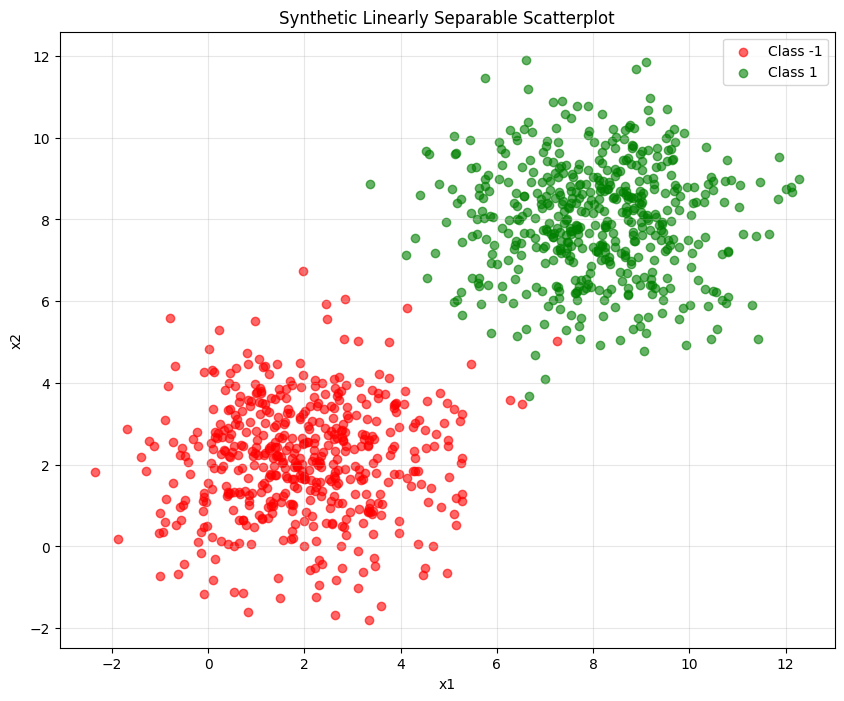

In [10]:
# Answer Q3 here

plt.figure(figsize=(10, 8))

# plotting points with label -1 in red

plt.scatter(df[df['label'] == -1]['x1'], 
           df[df['label'] == -1]['x2'], 
           color='red', 
           alpha=0.6, 
           label='Class -1')

# plotting points with label 1 in green

plt.scatter(df[df['label'] == 1]['x1'], 
           df[df['label'] == 1]['x2'], 
           color='green', 
           alpha=0.6, 
           label='Class 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Synthetic Linearly Separable Scatterplot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Q4 (2 points). Train/Test split

Split df into train and test sets using sklearn.

In [ ]:
# Answer Q4 here

# splitting the data into features and labels 

X = df[['x1', 'x2']].values
y = df['label'].values

# splitting into train and test sets (80% train, 20% test) --> 800, 200

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 800
Test set size: 200


# Perceptron implementation

## Q5 (2 points). Implement a function that takes a vector x, a vector of weights w, a bias b, and returns 1 if x would be classified as 1 by the Perceptron given the weights and bias, and -1 otherwise.
You can assume that x and w have 2 elements each if that helps.

In [12]:
# Answer Q5 here
def predict_datapoint(x, w, b):
  """
  Predict the class of a single datapoint
  Returns 1 if w·x + b > 0, else -1
  """
  if np.dot(w, x) + b > 0:
        return 1
  else:
        return -1

## Q6 (2 points). Implement a function that takes a list of vectors X (each element is a vector), a vector of weights w, a bias b, and returns a list of predictions, one for each element in X.
Use `predict_datapoint`.

In [13]:
# Answer Q6 here
def predict_data(X, w, b):
    """
    Predict classes for multiple datapoints
    Returns a list of predictions
    """
    predictions = []
    for x in X:
        pred = predict_datapoint(x, w, b)
        predictions.append(pred)
    return predictions

## Q7 (2 points). Implement a function that takes a vector x, its ground truth y, a vector of weights w, a bias b, a learning rate, and returns new weights and bias.
This function would be called inside the main Perceptron function (in case the current prediction for x is not equal to the ground truth) to adjust the weights and bias.

In [14]:
# Answer Q7 here
# You can assume x and w are np.arrays
def update_weights(x, y, w, b, learning_rate):
    """
    Update weights and bias using the Perceptron learning rule
    w_new = w + learning_rate * y * x
    b_new = b + learning_rate * y
    """
    w_new = w + learning_rate * y * x
    b_new = b + learning_rate * y
    return w_new, b_new

## Q8 (1 point). Initialize the learning rate to 0.1, the bias to 0, the weights to a list of two 0s, and the errors per epoch to an empty list. Make sure all the numbers are float numbers.

In [15]:
# Answer Q8 here
learning_rate = 0.1

bias = 0.0
weights = np.array([0.0, 0.0])

errors_per_epoch = []

## Q9 (16 points). Write the Perceptron function

You should have an outer loop that iterates over epochs. Put something like 1000 epochs to go through (unless the algorithm converges earlier -- see the last sentence).

Keep track of the number of errors in the epoch.

Inside the loop, iterate over the training examples.

For each training point, make prediction on it using `predict_datapoint`, compare that to the ground truth, and adjust the weights if needed using `update_weights`.

After the epoch concludes, put the number of errors in `errors_per_epoch` which will be a list of errors per epoch.

At the end of each epoch, print its number (the first epoch should have number 1), the weights and bias, and the number of errors. Make sure to use text in addition to values to make it clear what number means what.

If the number of errors in the epoch is 0 at the end of an epoch, print "Success!," the final weights and bias, and stop the algorithm.

In [ ]:
# Answer Q9 here
def perceptron(X_data, y_data, l_rate, w, b, e_per_ep):
    """
    Perceptron learning algorithm
    """
    # continue until convergence or max epochs
    
    max_epochs = 1000
    
    for epoch in range(1, max_epochs + 1):
        errors = 0
        
        # iterating over all training examples
        
        for i in range(len(X_data)):
            x_i = X_data[i]
            y_i = y_data[i]
            
            # making prediction
            
            prediction = predict_datapoint(x_i, w, b)
            
            # if prediction is wrong, update weights
            
            if prediction != y_i:
                w, b = update_weights(x_i, y_i, w, b, l_rate)
                errors += 1
        
        # store errors for this epoch
        
        e_per_ep.append(errors)
        
        # print epoch information
        
        print(f"Epoch {epoch}: Weights = {w}, Bias = {b}, Errors = {errors}")
        
        # convergence check
        
        if errors == 0:
            print("Success!")
            print(f"Final weights: {w}")
            print(f"Final bias: {b}")
            break
    
    return w, b

In [17]:
# Run this cell to run the algorithm (and check your Q9 code)
# You are calling the function on the actual objects that you have, e.g. X_train, which will take the place of X_data in the function itself
perceptron(X_train, y_train, learning_rate, weights, bias, errors_per_epoch)

Epoch 1: Weights = [0.27628521 0.27724113], Bias = -3.0000000000000013, Errors = 64
Epoch 2: Weights = [0.18513079 0.49169423], Bias = -4.100000000000001, Errors = 29
Epoch 3: Weights = [0.59500153 0.33398626], Bias = -5.699999999999996, Errors = 44
Epoch 4: Weights = [0.5612063  0.43440414], Bias = -6.099999999999994, Errors = 16
Epoch 5: Weights = [0.4967828  0.54876686], Bias = -6.499999999999993, Errors = 16
Epoch 6: Weights = [0.59424567 0.57629216], Bias = -6.8999999999999915, Errors = 18
Epoch 7: Weights = [0.62924257 0.6783613 ], Bias = -7.099999999999991, Errors = 10
Epoch 8: Weights = [0.64308498 0.74408182], Bias = -7.699999999999989, Errors = 22
Epoch 9: Weights = [0.74846636 0.78196755], Bias = -8.099999999999987, Errors = 16
Epoch 10: Weights = [0.65921254 0.9175052 ], Bias = -8.399999999999986, Errors = 15
Epoch 11: Weights = [1.52700351 1.20282715], Bias = -8.599999999999985, Errors = 14
Epoch 12: Weights = [1.02217115 0.5890087 ], Bias = -8.999999999999984, Errors = 14

(array([2.69287749, 3.43559466]), np.float64(-32.20000000000019))

## Q10 (2 points). Plot training diagnostics

Plot the number of errors per epoch to see convergence behavior. Give your plot a title and label the axes appropriately.

Epoch 1: Weights = [0.27628521 0.27724113], Bias = -3.0000000000000013, Errors = 64
Epoch 2: Weights = [0.18513079 0.49169423], Bias = -4.100000000000001, Errors = 29
Epoch 3: Weights = [0.59500153 0.33398626], Bias = -5.699999999999996, Errors = 44
Epoch 4: Weights = [0.5612063  0.43440414], Bias = -6.099999999999994, Errors = 16
Epoch 5: Weights = [0.4967828  0.54876686], Bias = -6.499999999999993, Errors = 16
Epoch 6: Weights = [0.59424567 0.57629216], Bias = -6.8999999999999915, Errors = 18
Epoch 7: Weights = [0.62924257 0.6783613 ], Bias = -7.099999999999991, Errors = 10
Epoch 8: Weights = [0.64308498 0.74408182], Bias = -7.699999999999989, Errors = 22
Epoch 9: Weights = [0.74846636 0.78196755], Bias = -8.099999999999987, Errors = 16
Epoch 10: Weights = [0.65921254 0.9175052 ], Bias = -8.399999999999986, Errors = 15
Epoch 11: Weights = [1.52700351 1.20282715], Bias = -8.599999999999985, Errors = 14
Epoch 12: Weights = [1.02217115 0.5890087 ], Bias = -8.999999999999984, Errors = 14

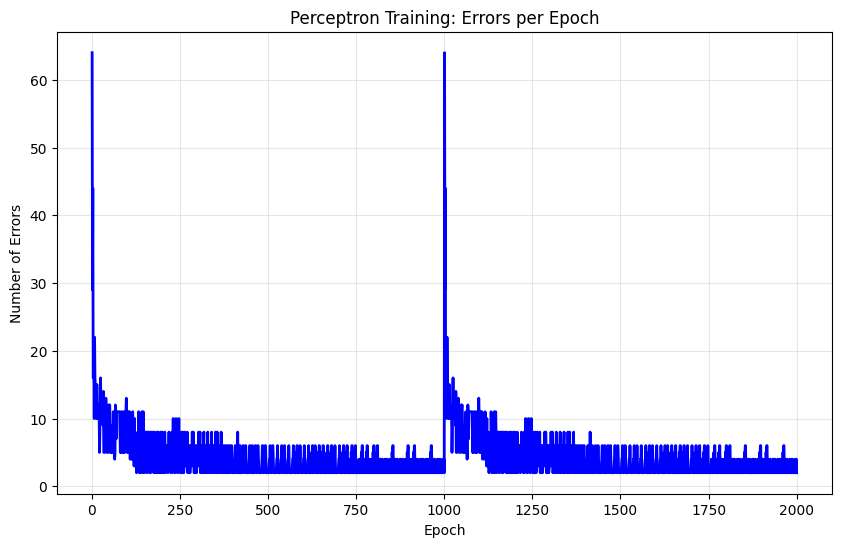

In [18]:
# Answer Q10 here

# run the algorithm if not already done

final_w, final_b = perceptron(X_train, y_train, learning_rate, weights, bias, errors_per_epoch)

# plot errors per epoch

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(errors_per_epoch) + 1), errors_per_epoch, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Number of Errors')
plt.title('Perceptron Training: Errors per Epoch')
plt.grid(True, alpha=0.3)
plt.show()

## Q11 (5 points). Calculate the training accuracy for your final weights and bias.
Use `predict_data`.

In [19]:
# Answer Q11 here

# make predictions on training data

train_predictions = predict_data(X_train, final_w, final_b)

# calculating accuracy

train_correct = sum(1 for pred, true in zip(train_predictions, y_train) if pred == true)
train_accuracy = train_correct / len(y_train) * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Correct predictions: {train_correct} out of {len(y_train)}")

Training Accuracy: 99.88%
Correct predictions: 799 out of 800


## Q12 (2 points). Calculate the test accuracy for your final weights and bias.
Use `predict_data`.

In [20]:
# Answer Q12 here

# make predictions on test data

test_predictions = predict_data(X_test, final_w, final_b)

# calculate accuracy

test_correct = sum(1 for pred, true in zip(test_predictions, y_test) if pred == true)
test_accuracy = test_correct / len(y_test) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct predictions: {test_correct} out of {len(y_test)}")

Test Accuracy: 99.50%
Correct predictions: 199 out of 200


## Q13 (5 points) Visualize the decision boundary

Plot the test points (colored by their ground truth) ONLY, along with the linear decision boundary defined by the learned weights. For 2D, the line is: w1 x1 + w2 x2 + b = 0, or x2 = -(w1/w2) * x1 - b/w2.

Use the same legend and axes labels as in Q3.

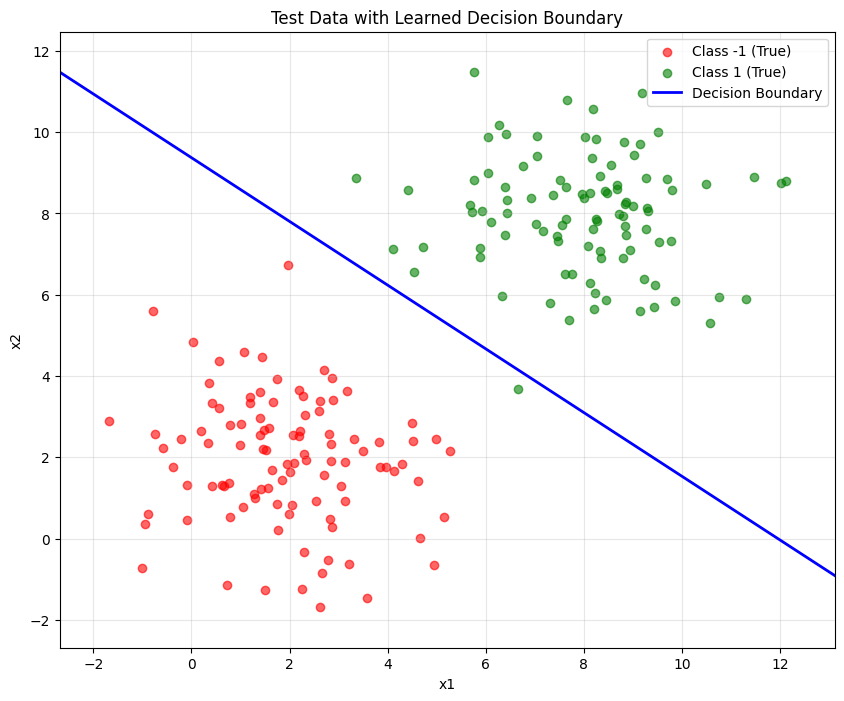

In [21]:
# Answer Q13 here

plt.figure(figsize=(10, 8))

# plot test points

plt.scatter(X_test[y_test == -1][:, 0], 
           X_test[y_test == -1][:, 1], 
           color='red', 
           alpha=0.6, 
           label='Class -1 (True)')

plt.scatter(X_test[y_test == 1][:, 0], 
           X_test[y_test == 1][:, 1], 
           color='green', 
           alpha=0.6, 
           label='Class 1 (True)')

# plot decision boundary: w1*x1 + w2*x2 + b = 0
# solve for x2: x2 = -(w1/w2)*x1 - b/w2

w1, w2 = final_w
x1_range = np.array([X_test[:, 0].min() - 1, X_test[:, 0].max() + 1])
x2_boundary = -(w1/w2) * x1_range - final_b/w2

plt.plot(x1_range, x2_boundary, 'b-', linewidth=2, label='Decision Boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Test Data with Learned Decision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(X_test[:, 0].min() - 1, X_test[:, 0].max() + 1)
plt.ylim(X_test[:, 1].min() - 1, X_test[:, 1].max() + 1)
plt.show()

## Q14 (1 point). Feedback

Please share what you enjoyed and didn't enjoy about this assignment and how long it took for you to do it.

*Answer Q14 here*

I enjoyed implementing the Perceptron algorithm from scratch and seeing how it can converge on linearly separable data only. The visuals were also helpful for seeing the decision boundary in the midst of x1 and x2 features combined with weights. It took me around an hour and a half to complete due to my lack of initial understanding around the documentation for the perceptron algorithm. However, the challenges were worth it in end as I feel like I learned alot. 

## Submitting your work

### Congrats on finishing PA7!

*   Save this notebook (`File > Save`).
*   Download it to your computer as `.ipynb` (`File > Download > Download .ipynb`).
*   Submit the .ipynb file on Canvas.

Tips:
*   After finishing the work, click on the arrow to the right of "Run all" and then click on "Clear all outputs" and "Restart session." Then run each cell in order to make sure everything compiles.
*   Remember to delete the cells you created for testing and any Gemini-affected cells if you used help from Gemini.